# Fig5: radial 10-m wind-speed profiles

Read each model's recalculated d02 typhoon center, compute WGS84 geodesic distance, then average 10-m wind speed in 10-km annuli from 0 to 300 km. Ragasa and Yagi are exported as separate figures.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from pyproj import Geod


MODEL_STYLES = {
    "era5": {"label": "ERA5_WRF", "color": "#4c78a8", "marker": "x"},
    "pangu": {"label": "Pangu_WRF", "color": "#f58518", "marker": "s"},
    "graphcast": {"label": "GraphCast_WRF", "color": "#54a24b", "marker": "^"},
    "fengwu": {"label": "FengWu_WRF", "color": "#e45756", "marker": "D"},
    "fuxi": {"label": "FuXi_WRF", "color": "#72b7b2", "marker": "v"},
    "aurora": {"label": "Aurora_WRF", "color": "#b279a2", "marker": "p"},
}

CASE_CONFIG = {
    "ragasa": {
        "display_name": "Ragasa",
        "target_time": pd.Timestamp("2025-09-23 22:00:00"),
        "output_name": "radial_wind_profile_ragasa_d02.tif",
    },
    "yagi": {
        "display_name": "Yagi",
        "target_time": pd.Timestamp("2024-09-05 12:00:00"),
        "output_name": "radial_wind_profile_yagi_d02.tif",
    },
}

BIN_WIDTH_KM = 10.0
MAX_RADIUS_KM = 300.0
FIGSIZE = (7.0, 5.5)
DPI = 600
GEOD = Geod(ellps="WGS84")

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 14


In [2]:
def find_workspace_root() -> Path:
    """Locate the workspace from either its root or the Fig5 directory."""
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    if cwd.name.lower() == "fig5":
        candidates.insert(0, cwd.parent)

    for candidate in candidates:
        if (candidate / "Fig5" / "input" / "ragasa").is_dir() and (candidate / "Fig5" / "input" / "yagi").is_dir():
            return candidate
    raise FileNotFoundError(f"Could not locate Fig5/input/{{ragasa,yagi}} from {cwd}")


def wind_file_path(root: Path, storm: str, model: str, target_time: pd.Timestamp) -> Path:
    stamp = target_time.strftime("%Y-%m-%d_%HUTC")
    return root / "Fig5" / "input" / storm / f"24h_{model}_uv10_d02_{stamp}.nc"


def load_d02_center(root: Path, storm: str, model: str) -> dict[str, float]:
    center_path = (
        root / "Fig5" / "input" / storm
        / f"location_{storm}_{model}_24h_d02.txt"
    )
    if not center_path.is_file():
        raise FileNotFoundError(f"Missing d02 center file: {center_path}")

    values = np.atleast_2d(np.loadtxt(center_path))
    if values.shape != (1, 3):
        raise ValueError(f"Expected one lon/lat/SLP row in {center_path}; got {values.shape}")
    if not np.isfinite(values).all():
        raise ValueError(f"Non-finite center coordinate or SLP in {center_path}")

    lon, lat, slp_hpa = values[0]
    if not (-180.0 <= lon <= 180.0 and -90.0 <= lat <= 90.0):
        raise ValueError(f"Invalid center longitude/latitude in {center_path}: {lon}, {lat}")
    return {
        "center_lon": float(lon),
        "center_lat": float(lat),
        "slp_hpa": float(slp_hpa),
        "center_path": center_path,
    }


def load_wind_snapshot(path: Path) -> dict[str, np.ndarray]:
    if not path.is_file():
        raise FileNotFoundError(f"Missing d02 wind file: {path}")

    with xr.open_dataset(path) as ds:
        required = {"U10", "V10", "LAT", "LON"}
        missing = sorted(required - set(ds.variables))
        if missing:
            raise KeyError(f"Missing variables {missing} in {path}")
        arrays = {name: np.asarray(ds[name].squeeze().values).copy() for name in required}

    shapes = {name: array.shape for name, array in arrays.items()}
    if any(len(shape) != 2 for shape in shapes.values()) or len(set(shapes.values())) != 1:
        raise ValueError(f"Expected matching 2-D U10/V10/LAT/LON arrays in {path}; got {shapes}")
    if not all(np.isfinite(arrays[name]).all() for name in required):
        raise ValueError(f"Non-finite wind or coordinate values in {path}")
    return arrays


def geodesic_distance_km(
    lon: np.ndarray, lat: np.ndarray, center_lon: float, center_lat: float
) -> np.ndarray:
    """Vectorized WGS84 geodesic distance from the typhoon center."""
    center_lons = np.full(lon.shape, center_lon, dtype=float)
    center_lats = np.full(lat.shape, center_lat, dtype=float)
    _, _, distance_m = GEOD.inv(center_lons, center_lats, lon, lat)
    return np.asarray(distance_m) / 1000.0


def minimum_boundary_distance_km(
    lon: np.ndarray, lat: np.ndarray, center_lon: float, center_lat: float
) -> float:
    boundary_lon = np.concatenate([lon[0, :], lon[-1, :], lon[1:-1, 0], lon[1:-1, -1]])
    boundary_lat = np.concatenate([lat[0, :], lat[-1, :], lat[1:-1, 0], lat[1:-1, -1]])
    distances = geodesic_distance_km(boundary_lon, boundary_lat, center_lon, center_lat)
    return float(np.min(distances))


def radial_profile(
    distance_km: np.ndarray, speed: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    edges = np.arange(0.0, MAX_RADIUS_KM + BIN_WIDTH_KM, BIN_WIDTH_KM)
    radii = 0.5 * (edges[:-1] + edges[1:])
    means = np.full(radii.shape, np.nan, dtype=float)
    counts = np.zeros(radii.shape, dtype=int)

    for index, (lower, upper) in enumerate(zip(edges[:-1], edges[1:])):
        values = speed[(distance_km >= lower) & (distance_km < upper)]
        counts[index] = values.size
        if values.size:
            means[index] = float(np.mean(values))

    if np.any(counts == 0) or not np.isfinite(means).all():
        raise ValueError("Every radial annulus must contain finite wind-speed samples")
    return radii, means, counts


In [3]:
root = find_workspace_root()
output_dir = root / "Fig5" / "output"
output_dir.mkdir(parents=True, exist_ok=True)

profile_rows: list[dict] = []
center_rows: list[dict] = []

for storm, config in CASE_CONFIG.items():
    reference_shape = None
    for model in MODEL_STYLES:
        center = load_d02_center(root, storm, model)
        path = wind_file_path(root, storm, model, config["target_time"])
        fields = load_wind_snapshot(path)

        if reference_shape is None:
            reference_shape = fields["LAT"].shape
        elif fields["LAT"].shape != reference_shape:
            raise ValueError(f"Grid shape differs within {storm}: {path}")

        speed = np.hypot(fields["U10"], fields["V10"])
        distance_km = geodesic_distance_km(
            fields["LON"], fields["LAT"], center["center_lon"], center["center_lat"]
        )
        boundary_distance_km = minimum_boundary_distance_km(
            fields["LON"], fields["LAT"], center["center_lon"], center["center_lat"]
        )
        if boundary_distance_km <= MAX_RADIUS_KM:
            raise ValueError(
                f"{storm} {model} center is only {boundary_distance_km:.1f} km from the "
                f"d02 boundary; cannot form complete {MAX_RADIUS_KM:.0f}-km annuli"
            )

        radii, mean_speed, counts = radial_profile(distance_km, speed)
        center_rows.append(
            {
                "storm": config["display_name"],
                "model": MODEL_STYLES[model]["label"],
                "valid_time_utc": config["target_time"],
                "center_lon": center["center_lon"],
                "center_lat": center["center_lat"],
                "slp_hpa": center["slp_hpa"],
                "minimum_boundary_distance_km": boundary_distance_km,
            }
        )
        for radius, wind_speed, count in zip(radii, mean_speed, counts):
            profile_rows.append(
                {
                    "storm": storm,
                    "model": model,
                    "radius_km": radius,
                    "wind_speed_ms": wind_speed,
                    "gridpoint_count": count,
                }
            )

profiles = pd.DataFrame(profile_rows)
centers = pd.DataFrame(center_rows)

expected_profile_rows = len(CASE_CONFIG) * len(MODEL_STYLES) * int(MAX_RADIUS_KM / BIN_WIDTH_KM)
if len(profiles) != expected_profile_rows:
    raise RuntimeError(f"Expected {expected_profile_rows} profile rows; got {len(profiles)}")

display(centers.round({"center_lon": 4, "center_lat": 4, "slp_hpa": 2, "minimum_boundary_distance_km": 1}))


,storm,model,valid_time_utc,center_lon,center_lat,slp_hpa,minimum_boundary_distance_km
0,Ragasa,ERA5_WRF,2025-09-23 22:00:00,114.5193,21.7105,942.66,641.5
1,Ragasa,Pangu_WRF,2025-09-23 22:00:00,114.6068,21.3850,942.89,605.4
2,Ragasa,GraphCast_WRF,2025-09-23 22:00:00,114.5193,21.7918,944.10,650.5
3,Ragasa,FengWu_WRF,2025-09-23 22:00:00,114.7818,21.7105,943.35,641.5
4,Ragasa,FuXi_WRF,2025-09-23 22:00:00,114.3443,21.6292,943.21,632.5
5,Ragasa,Aurora_WRF,2025-09-23 22:00:00,114.6068,21.7918,946.03,650.5
6,Yagi,ERA5_WRF,2024-09-05 12:00:00,114.7818,19.6640,944.23,414.9
7,Yagi,Pangu_WRF,2024-09-05 12:00:00,114.8693,19.4166,932.29,387.5
8,Yagi,GraphCast_WRF,2024-09-05 12:00:00,114.6943,19.5816,932.17,405.8
9,Yagi,FengWu_WRF,2024-09-05 12:00:00,114.6943,19.6640,932.60,414.9


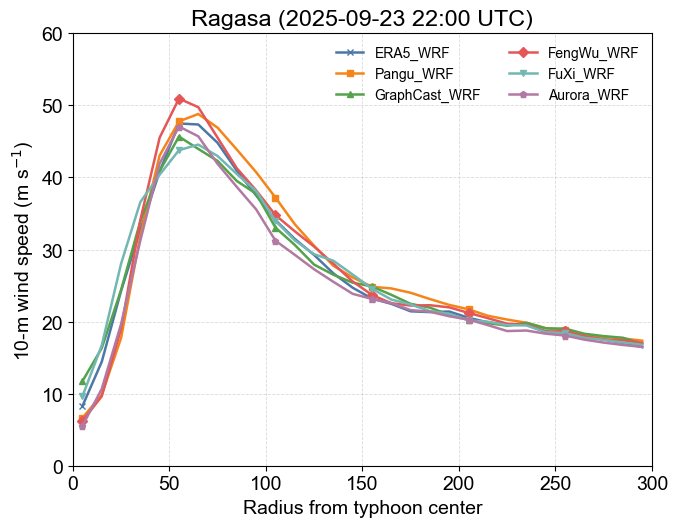

Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig5\output\radial_wind_profile_ragasa_d02.tif


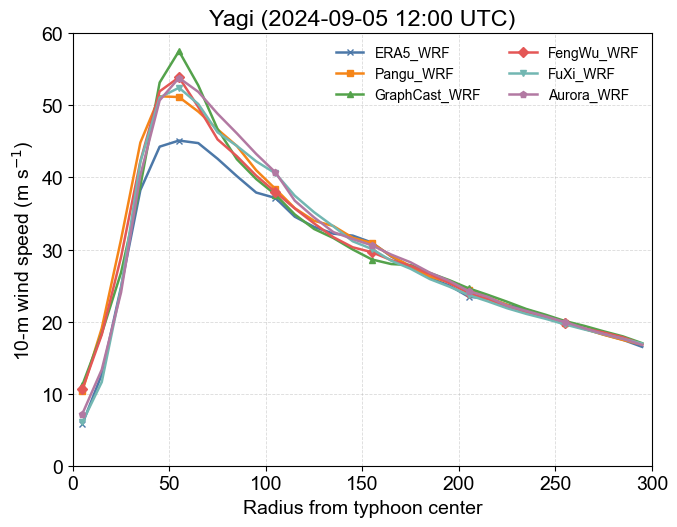

Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig5\output\radial_wind_profile_yagi_d02.tif


In [4]:
global_ymax = 5.0 * np.ceil(profiles["wind_speed_ms"].max() / 5.0)
generated_paths: list[Path] = []

for storm, config in CASE_CONFIG.items():
    fig, ax = plt.subplots(figsize=FIGSIZE)
    storm_profiles = profiles.loc[profiles["storm"] == storm]

    for model, style in MODEL_STYLES.items():
        model_profile = storm_profiles.loc[storm_profiles["model"] == model]
        ax.plot(
            model_profile["radius_km"],
            model_profile["wind_speed_ms"],
            label=style["label"],
            color=style["color"],
            marker=style["marker"],
            markevery=5,
            markersize=5,
            linewidth=1.8,
        )

    ax.set_xlim(0, MAX_RADIUS_KM)
    ax.set_ylim(0, global_ymax)
    ax.set_xticks(np.arange(0, MAX_RADIUS_KM + 1, 50))
    ax.set_xlabel("Radius from typhoon center")
    ax.set_ylabel(r"10-m wind speed (m s$^{-1}$)")
    ax.set_title(f"{config['display_name']} ({config['target_time'].strftime('%Y-%m-%d %H:%M UTC')})")
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.45)
    ax.legend(frameon=False, fontsize=10, ncol=2)
    fig.tight_layout()

    output_path = output_dir / config["output_name"]
    fig.savefig(
        output_path,
        dpi=DPI,
        format="tiff",
        bbox_inches="tight",
        pil_kwargs={"compression": "tiff_lzw"},
    )
    plt.show()
    plt.close(fig)
    generated_paths.append(output_path)
    print(f"Saved: {output_path}")

if len(generated_paths) != 2 or any(not path.is_file() or path.stat().st_size == 0 for path in generated_paths):
    raise RuntimeError("Expected two non-empty radial-profile TIFF files")


In [5]:
HONG_KONG_LON = 114.1
HONG_KONG_LAT = 22.3

def load_jma_best_track_position(
    root: Path, storm: str, target_time: pd.Timestamp
) -> dict[str, object]:
    path = root / "Fig5" / "input" / f"best_track_{storm}_JMA.xlsx"
    if not path.is_file():
        raise FileNotFoundError(f"Missing JMA best-track file: {path}")

    raw = pd.read_excel(path)
    required = {"Time", "Lat", "Lon"}
    missing = sorted(required - set(raw.columns))
    if missing:
        raise KeyError(f"Missing JMA columns {missing} in {path}")

    track = pd.DataFrame(
        {
            "time": pd.to_datetime(raw["Time"].astype(str), format="%y%m%d%H"),
            "lat": pd.to_numeric(raw["Lat"], errors="raise") / 10.0,
            "lon": pd.to_numeric(raw["Lon"], errors="raise") / 10.0,
        }
    ).sort_values("time")
    if track["time"].duplicated().any():
        raise ValueError(f"Duplicate JMA times in {path}")

    exact = track.loc[track["time"] == target_time]
    if len(exact) == 1:
        row = exact.iloc[0]
        return {"center_lon": row["lon"], "center_lat": row["lat"], "position_source": "JMA exact"}

    before = track.loc[track["time"] < target_time]
    after = track.loc[track["time"] > target_time]
    if before.empty or after.empty:
        raise ValueError(f"Cannot bracket {target_time} in {path}")
    before_row = before.iloc[-1]
    after_row = after.iloc[0]
    fraction = (target_time - before_row["time"]) / (after_row["time"] - before_row["time"])
    center_lon = before_row["lon"] + fraction * (after_row["lon"] - before_row["lon"])
    center_lat = before_row["lat"] + fraction * (after_row["lat"] - before_row["lat"])
    source = (
        "JMA linear interpolation "
        f"({before_row['time']:%Y-%m-%d %H:%M} to {after_row['time']:%Y-%m-%d %H:%M} UTC)"
    )
    return {"center_lon": center_lon, "center_lat": center_lat, "position_source": source}


center_to_hong_kong = centers[
    ["storm", "model", "valid_time_utc", "center_lon", "center_lat"]
].copy()
center_to_hong_kong["position_source"] = "d02 minimum SLP"
_, _, distance_to_hong_kong_m = GEOD.inv(
    center_to_hong_kong["center_lon"].to_numpy(),
    center_to_hong_kong["center_lat"].to_numpy(),
    np.full(len(center_to_hong_kong), HONG_KONG_LON),
    np.full(len(center_to_hong_kong), HONG_KONG_LAT),
)
center_to_hong_kong["distance_to_hong_kong_km"] = distance_to_hong_kong_m / 1000.0

best_track_rows = []
for storm_key, config in CASE_CONFIG.items():
    position = load_jma_best_track_position(
        root, config["display_name"], config["target_time"]
    )
    _, _, distance_m = GEOD.inv(
        position["center_lon"], position["center_lat"], HONG_KONG_LON, HONG_KONG_LAT
    )
    best_track_rows.append(
        {
            "storm": config["display_name"],
            "model": "JMA best track",
            "valid_time_utc": config["target_time"],
            "center_lon": position["center_lon"],
            "center_lat": position["center_lat"],
            "position_source": position["position_source"],
            "distance_to_hong_kong_km": distance_m / 1000.0,
        }
    )

best_track_to_hong_kong = pd.DataFrame(best_track_rows)
summary_parts = []
for config in CASE_CONFIG.values():
    storm_name = config["display_name"]
    summary_parts.append(center_to_hong_kong.loc[center_to_hong_kong["storm"] == storm_name])
    summary_parts.append(best_track_to_hong_kong.loc[best_track_to_hong_kong["storm"] == storm_name])
distance_summary = pd.concat(summary_parts, ignore_index=True)

print(f"Typhoon-center distance to Hong Kong ({HONG_KONG_LON} E, {HONG_KONG_LAT} N)")
print(
    distance_summary.to_string(
        index=False,
        formatters={
            "center_lon": "{:.4f}".format,
            "center_lat": "{:.4f}".format,
            "distance_to_hong_kong_km": "{:.1f}".format,
        },
    )
)


Typhoon-center distance to Hong Kong (114.1 E, 22.3 N)
 storm          model      valid_time_utc center_lon center_lat                                                     position_source distance_to_hong_kong_km
Ragasa       ERA5_WRF 2025-09-23 22:00:00   114.5193    21.7105                                                     d02 minimum SLP                     78.3
Ragasa      Pangu_WRF 2025-09-23 22:00:00   114.6068    21.3850                                                     d02 minimum SLP                    114.1
Ragasa  GraphCast_WRF 2025-09-23 22:00:00   114.5193    21.7918                                                     d02 minimum SLP                     71.0
Ragasa     FengWu_WRF 2025-09-23 22:00:00   114.7818    21.7105                                                     d02 minimum SLP                     96.0
Ragasa       FuXi_WRF 2025-09-23 22:00:00   114.3443    21.6292                                                     d02 minimum SLP                     78.4
Rag